# Q2 — Temperature Regime of Ice Clouds (December 2025)

**Research question:** Under what temperature regime do EarthCARE-detected ice clouds form?

**Approach:**
- Background: full zonal-mean temperature field (all valid ATL-TC pixels, Oct 2025–Feb 2026, 0.5° grid)  
- Overlay: Dec 2025 ice cloud occurrence fraction (ATL-TC ice mask, 1° grid)  
- Statistics: temperature distribution weighted by ice-pixel counts (Dec 2025)

In [153]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.ndimage import gaussian_filter

In [154]:
BASE    = Path("/Users/tobiasraucher/Python/KNMI")
OUT_DIR = BASE / "output/figures"
OUT_DIR.mkdir(exist_ok=True)

# Temperature background — full Oct 2025–Feb 2026 dataset (no ice mask)
TEMP_FILE  = BASE / "output/ATL_TC_2A_temperature_0.5deg_20251003_20260228_latheight.nc"

# Combined Dec 2025 — has occurrence + temperature at ice pixels
COMB_FILE  = BASE / "output/combined_all_1.0deg_20251201_20251231_latheight.nc"

MIN_COUNT  = 10       # minimum samples per grid cell
H_MAX_KM   = 20.0
H_MIN_KM   = 0.0

# Occurrence contour levels drawn on top of temperature background
OCC_LEVELS = [0.05, 0.10, 0.20, 0.30]

In [155]:
# ── Temperature background (0.5° grid, ascending height) ─────────────────────
ds_t  = xr.open_dataset(TEMP_FILE)
lat_t = ds_t["latitude"].values          # shape (360,)
h_t   = ds_t["height"].values / 1000.0   # m → km, shape (201,), ascending
cnt_t = ds_t["temp_count"].values
tmp   = ds_t["temperature"].values.copy()
ds_t.close()

# Mask cells with too few samples
tmp[cnt_t < MIN_COUNT] = np.nan

# Restrict to valid height range
h_mask_t = (h_t >= H_MIN_KM) & (h_t <= H_MAX_KM)
h_t_plot  = h_t[h_mask_t]
tmp_plot  = tmp[:, h_mask_t]           # shape (360, n_heights)

print(f"Temperature grid : lat {lat_t[0]:.2f}..{lat_t[-1]:.2f}°,  "
      f"height {h_t_plot[0]:.1f}..{h_t_plot[-1]:.1f} km  shape={tmp_plot.shape}")
print(f"  T range (valid): {np.nanmin(tmp_plot):.1f}..{np.nanmax(tmp_plot):.1f} K")

# ── Combined Dec 2025 (1° grid, descending height) ───────────────────────────
ds_c   = xr.open_dataset(COMB_FILE)
lat_c  = ds_c["latitude"].values          # shape (180,)
h_c    = ds_c["height"].values / 1000.0   # m → km, descending

occ    = ds_c["atl_tc_occurrence"].values
ice_t  = ds_c["atl_tc_temperature"].values
ice_n  = ds_c["atl_tc_ice_count"].values
tot_n  = ds_c["atl_tc_total_count"].values
iwc    = ds_c["iwc_mean"].values
ds_c.close()

# Mask low-sample cells; restrict to valid height range
h_mask_c = (h_c >= H_MIN_KM) & (h_c <= H_MAX_KM)
h_c_plot  = h_c[h_mask_c]

occ_plot   = occ[:, h_mask_c].copy()
ice_t_plot = ice_t[:, h_mask_c].copy()
ice_n_plot = ice_n[:, h_mask_c].copy()
iwc_plot   = iwc[:, h_mask_c].copy()

insufficient = tot_n[:, h_mask_c] < MIN_COUNT
occ_plot[insufficient]   = np.nan
ice_t_plot[insufficient] = np.nan
iwc_plot[insufficient | (ice_n[:, h_mask_c] < MIN_COUNT)] = np.nan

print(f"\nOccurrence grid : lat {lat_c[0]:.1f}..{lat_c[-1]:.1f}°,  "
      f"height {h_c_plot[-1]:.1f}..{h_c_plot[0]:.1f} km  shape={occ_plot.shape}")
print(f"  Occurrence range: {np.nanmin(occ_plot):.3f}..{np.nanmax(occ_plot):.3f}")

Temperature grid : lat -89.75..89.75°,  height 0.0..20.0 km  shape=(360, 201)
  T range (valid): 190.9..299.5 K

Occurrence grid : lat -89.5..89.5°,  height 0.1..19.9 km  shape=(180, 194)
  Occurrence range: 0.000..0.412


## Figure T1 — Zonal-mean temperature with ice occurrence overlay

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_23448/3495287326.py:31: RuntimeWarning: invalid value encountered in divide
  occ_smooth = np.where(s_wts > 0.1, s_vals / s_wts, np.nan)


Saved T1_temperature_ice_occurrence_overlay.png


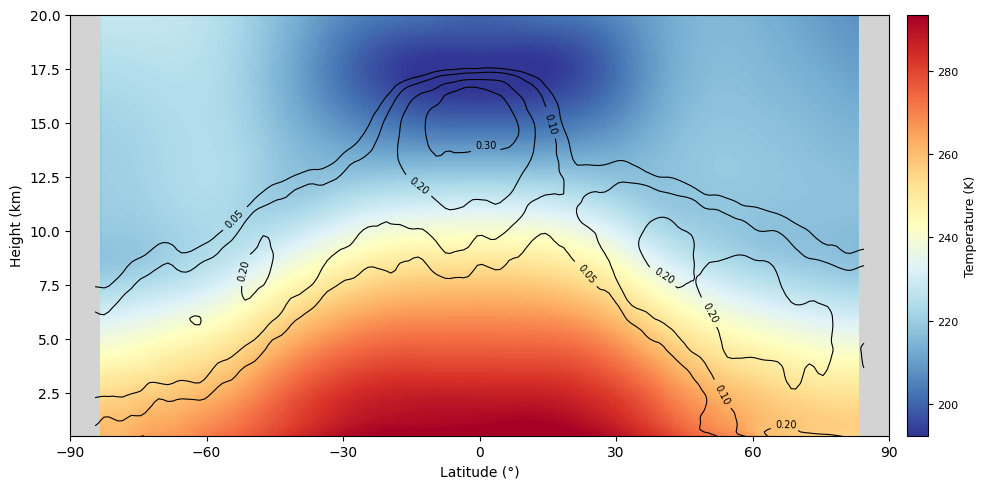

In [156]:
fig, ax = plt.subplots(figsize=(10, 5))

# ── Background: full temperature field ───────────────────────────────────────
t_vmin = np.nanpercentile(tmp_plot, 1)
t_vmax = np.nanpercentile(tmp_plot, 99)

mesh = ax.pcolormesh(
    lat_t, h_t_plot, tmp_plot.T,
    cmap="RdYlBu_r", vmin=t_vmin, vmax=t_vmax,
    shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, label="Temperature (K)", pad=0.02, fraction=0.046)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Temperature (K)", fontsize=9)

# Annotate data range below colorbar
# ax.text(
#     0.5, -0.12,
#     f"Data Min = {np.nanmin(tmp_plot):.1f},  Max = {np.nanmax(tmp_plot):.1f}",
#     transform=ax.transAxes, ha="center", fontsize=8, color="0.4",
# )

# ── Overlay: Dec 2025 ice cloud occurrence (contour lines only) ───────────────
# Smooth occurrence lightly before contouring for clean lines
occ_smooth = occ_plot.copy()
nan_mask   = np.isnan(occ_smooth)
filled     = np.where(nan_mask, 0.0, occ_smooth)
weights    = (~nan_mask).astype(float)
s_vals     = gaussian_filter(filled,  sigma=1.0)
s_wts      = gaussian_filter(weights, sigma=1.0)
occ_smooth = np.where(s_wts > 0.1, s_vals / s_wts, np.nan)

cs = ax.contour(
    lat_c, h_c_plot, occ_smooth.T,
    levels=OCC_LEVELS, colors="black", linewidths=0.8,
)
ax.clabel(cs, fmt="%.2f", fontsize=7, inline=True, inline_spacing=4)

# ── Axes ─────────────────────────────────────────────────────────────────────
ax.set_xlabel("Latitude (°)", fontsize=10)
ax.set_ylabel("Height (km)", fontsize=10)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(0.5, H_MAX_KM)
ax.set_facecolor("lightgrey")

plt.tight_layout()
plt.savefig(OUT_DIR / "T1_temperature_ice_occurrence_overlay.png", dpi=300, bbox_inches="tight")
print("Saved T1_temperature_ice_occurrence_overlay.png")
plt.show()

## Temperature regime statistics — Dec 2025 ice cloud pixels

Each grid cell in `ice_t_plot` holds the **mean temperature of all ice detections** in that cell.  
Statistics below are **weighted by `ice_n_plot`** (count of ice pixels per cell) so that
high-occurrence regions contribute proportionally.

In [157]:
# Flatten and apply mask
t_vals = ice_t_plot.ravel()
w_vals = ice_n_plot.ravel()

valid  = np.isfinite(t_vals) & np.isfinite(w_vals) & (w_vals >= MIN_COUNT)
t_v    = t_vals[valid]
w_v    = w_vals[valid]

# Weighted statistics helpers
def weighted_percentile(data, weights, perc):
    """Weighted percentile via sorted cumulative weights."""
    idx    = np.argsort(data)
    d_sort = data[idx]
    w_sort = weights[idx]
    cumw   = np.cumsum(w_sort) / w_sort.sum()
    return np.interp(perc / 100.0, cumw, d_sort)

w_mean   = np.average(t_v, weights=w_v)
w_var    = np.average((t_v - w_mean) ** 2, weights=w_v)
w_std    = np.sqrt(w_var)
percs    = [1, 5, 10, 25, 50, 75, 90, 95, 99]
wp       = {p: weighted_percentile(t_v, w_v, p) for p in percs}

print("=" * 52)
print("  Temperature at ice cloud pixels — December 2025")
print("  (weighted by ice-pixel count per 1° × 100 m cell)")
print("=" * 52)
print(f"  Valid grid cells : {valid.sum():,}")
print(f"  Total ice pixels : {w_v.sum():,.0f}")
print()
print(f"  Min              : {t_v.min():.1f} K  ({t_v.min()-273.15:.1f} °C)")
print(f"  Max              : {t_v.max():.1f} K  ({t_v.max()-273.15:.1f} °C)")
print(f"  Weighted mean    : {w_mean:.1f} K  ({w_mean-273.15:.1f} °C)")
print(f"  Weighted std dev : {w_std:.1f} K")
print()
print("  Weighted percentiles:")
for p in percs:
    print(f"    p{p:>2d}  :  {wp[p]:.1f} K  ({wp[p]-273.15:.1f} °C)")
print()
print(f"  IQR (p25–p75)    : {wp[25]:.1f}–{wp[75]:.1f} K  "
      f"({wp[25]-273.15:.1f}–{wp[75]-273.15:.1f} °C)")
print(f"  Central 90% (p5–p95): {wp[5]:.1f}–{wp[95]:.1f} K  "
      f"({wp[5]-273.15:.1f}–{wp[95]-273.15:.1f} °C)")

  Temperature at ice cloud pixels — December 2025
  (weighted by ice-pixel count per 1° × 100 m cell)
  Valid grid cells : 21,321
  Total ice pixels : 122,325,185

  Min              : 161.9 K  (-111.3 °C)
  Max              : 279.7 K  (6.5 °C)
  Weighted mean    : 228.0 K  (-45.1 °C)
  Weighted std dev : 17.6 K

  Weighted percentiles:
    p 1  :  188.4 K  (-84.7 °C)
    p 5  :  194.2 K  (-78.9 °C)
    p10  :  201.4 K  (-71.7 °C)
    p25  :  216.5 K  (-56.7 °C)
    p50  :  229.9 K  (-43.3 °C)
    p75  :  242.1 K  (-31.1 °C)
    p90  :  249.5 K  (-23.7 °C)
    p95  :  252.1 K  (-21.0 °C)
    p99  :  258.9 K  (-14.3 °C)

  IQR (p25–p75)    : 216.5–242.1 K  (-56.7–-31.1 °C)
  Central 90% (p5–p95): 194.2–252.1 K  (-78.9–-21.0 °C)


## Figure T2 — Histogram of ice cloud temperature distribution

## Figure T1b — Retrieval errors: ice detections above 0 °C

Grid cells  with T_ice > 0 °C : 219
Ice pixels  with T_ice > 0 °C : 5,184  (0.00% of all ice detections)
Temperature range in warm cells: 0.0..6.5 °C
Saved T1b_warm_ice_retrieval_errors.png


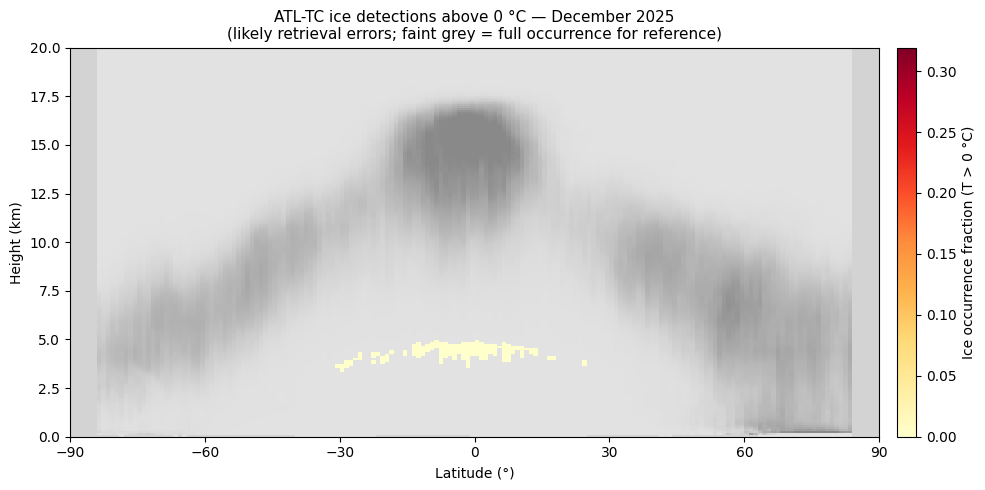

In [158]:
# Pixels where mean ice temperature > 0 °C — likely retrieval errors
warm_mask = ice_t_plot > 273.15
warm_occ  = np.where(warm_mask, occ_plot, np.nan)

n_warm_cells  = warm_mask.sum()
n_warm_pixels = ice_n_plot[warm_mask].sum()
frac_warm     = n_warm_pixels / w_v.sum() * 100

print(f"Grid cells  with T_ice > 0 °C : {n_warm_cells:,}")
print(f"Ice pixels  with T_ice > 0 °C : {n_warm_pixels:,.0f}  ({frac_warm:.2f}% of all ice detections)")
print(f"Temperature range in warm cells: "
      f"{ice_t_plot[warm_mask].min()-273.15:.1f}..{ice_t_plot[warm_mask].max()-273.15:.1f} °C")

fig, ax = plt.subplots(figsize=(10, 5))

# Grey background for context
ax.set_facecolor("lightgrey")

# Full occurrence as faint reference
ax.pcolormesh(lat_c, h_c_plot, occ_plot.T,
              cmap="Greys", vmin=0, vmax=np.nanpercentile(occ_plot, 99),
              shading="auto", alpha=0.35)

# Warm-ice occurrence highlighted
mesh = ax.pcolormesh(lat_c, h_c_plot, warm_occ.T,
                     cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(occ_plot, 99),
                     shading="auto")
plt.colorbar(mesh, ax=ax, label="Ice occurrence fraction (T > 0 °C)", pad=0.02, fraction=0.046)

ax.set_xlabel("Latitude (°)", fontsize=10)
ax.set_ylabel("Height (km)", fontsize=10)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(H_MIN_KM, H_MAX_KM)
ax.set_title(
    "ATL-TC ice detections above 0 °C — December 2025\n"
    "(likely retrieval errors; faint grey = full occurrence for reference)",
    fontsize=11,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "T1b_warm_ice_retrieval_errors.png", dpi=300, bbox_inches="tight")
print("Saved T1b_warm_ice_retrieval_errors.png")
plt.show()

Saved T2_ice_temperature_histogram.png


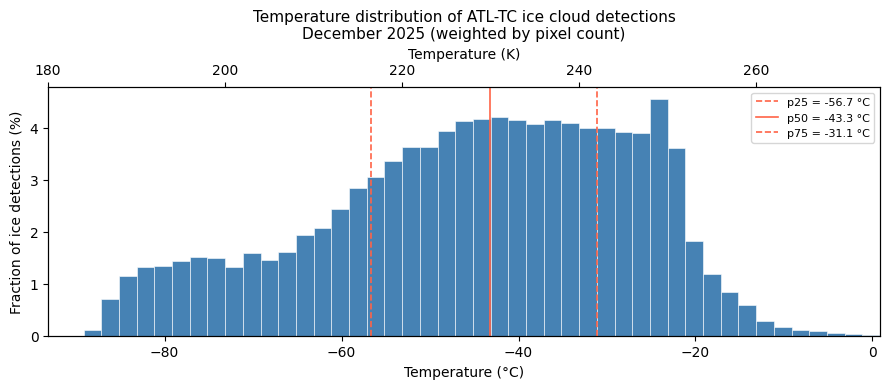

In [159]:
bins = np.arange(180, 275, 2)   # 2 K bins from 180 to 274 K

hist_counts, bin_edges = np.histogram(t_v, bins=bins, weights=w_v)
hist_frac = hist_counts / hist_counts.sum()
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(bin_centers - 273.15, hist_frac * 100, width=2.0,
       color="steelblue", edgecolor="white", linewidth=0.4)

# Percentile markers
for p, style in [(25, "--"), (50, "-"), (75, "--")]:
    ax.axvline(wp[p] - 273.15, color="tomato", linestyle=style, linewidth=1.2,
               label=f"p{p} = {wp[p]-273.15:.1f} °C")

ax.set_xlabel("Temperature (°C)", fontsize=10)
ax.set_ylabel("Fraction of ice detections (%)", fontsize=10)
ax.set_title("Temperature distribution of ATL-TC ice cloud detections\nDecember 2025 (weighted by pixel count)",
             fontsize=11)
ax.legend(fontsize=8, framealpha=0.8)
ax.set_xlim(bin_edges[0] - 273.15, bin_edges[-1] - 273.15)

# Secondary x-axis in Kelvin
ax2 = ax.twiny()
ax2.set_xlim(bin_edges[0], bin_edges[-1])
ax2.set_xlabel("Temperature (K)", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "T2_ice_temperature_histogram.png", dpi=300, bbox_inches="tight")
print("Saved T2_ice_temperature_histogram.png")
plt.show()

## Figures T3 & T4 — Temperature regime classification

| Zone | Range | Interpretation |
|------|-------|----------------|
| Retrieval error | > 0 °C | Ice physically impossible |
| Warm / unlikely | −20 °C to 0 °C | Supercooled liquid more likely |
| Mixed-phase | −38 °C to −20 °C | Ice + supercooled liquid coexist |
| Pure ice | −60 °C to −38 °C | Homogeneous freezing guaranteed |
| Deep convective | < −60 °C | Anvil / tropopause cirrus |

Saved T3_ice_temperature_zones_latheight.png


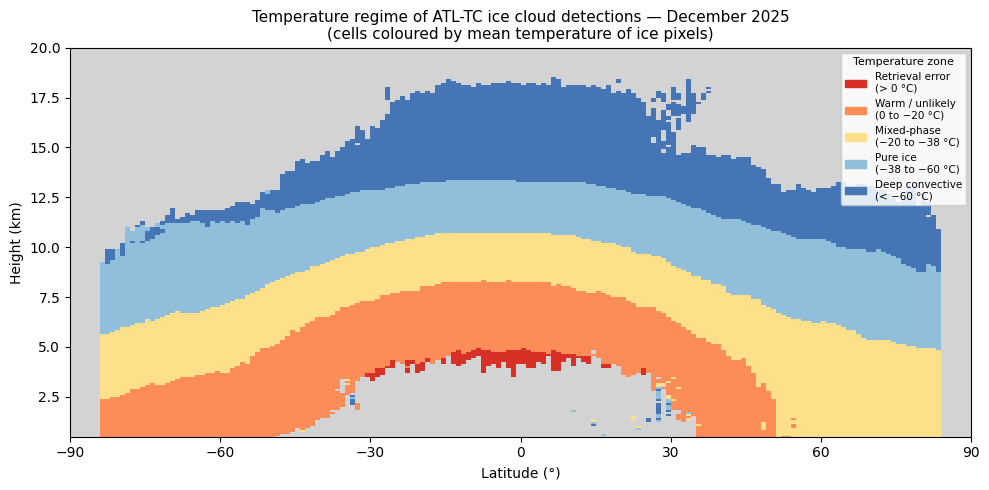


Fraction of ice pixels per zone (weighted by ice_count):
  Retrieval error (> 0 °C)           :        5,184 pixels  ( 0.00%)
  Warm / unlikely (0 to −20 °C)      :    4,856,037 pixels  ( 3.97%)
  Mixed-phase (−20 to −38 °C)        :   42,895,816 pixels  (35.07%)
  Pure ice (−38 to −60 °C)           :   49,613,123 pixels  (40.56%)
  Deep convective (< −60 °C)         :   24,955,025 pixels  (20.40%)


In [160]:
import matplotlib.patches as mpatches

# ── Zone boundaries (K) and display metadata ─────────────────────────────────
ZONES = [
    # (label,              T_low,   T_high,  colour)
    ("Retrieval error\n(> 0 °C)",         273.15,  999,    "#d73027"),
    ("Warm / unlikely\n(0 to −20 °C)",    253.15,  273.15, "#fc8d59"),
    ("Mixed-phase\n(−20 to −38 °C)",      235.15,  253.15, "#fee08b"),
    ("Pure ice\n(−38 to −60 °C)",         213.15,  235.15, "#91bfdb"),
    ("Deep convective\n(< −60 °C)",      -999,    213.15, "#4575b4"),
]

def classify(t_arr):
    """Return integer zone index (0–4) for each element; NaN stays NaN."""
    out = np.full(t_arr.shape, np.nan)
    for i, (_, lo, hi, _) in enumerate(ZONES):
        out[(t_arr > lo) & (t_arr <= hi)] = i
    return out

zone_map = classify(ice_t_plot)   # shape (lat, height), only where ice detected

# ── Figure T3 — Categorical lat-height cross-section ─────────────────────────
colors = [z[3] for z in ZONES]
cmap_z = mcolors.ListedColormap(colors)
norm_z = mcolors.BoundaryNorm(np.arange(-0.5, len(ZONES)), len(ZONES))

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor("lightgrey")

mesh = ax.pcolormesh(lat_c, h_c_plot, zone_map.T,
                     cmap=cmap_z, norm=norm_z, shading="auto")

# Legend patches
patches = [mpatches.Patch(color=z[3], label=z[0]) for z in ZONES]
ax.legend(handles=patches, loc="upper right", fontsize=7.5,
          framealpha=0.85, title="Temperature zone", title_fontsize=8)

ax.set_xlabel("Latitude (°)", fontsize=10)
ax.set_ylabel("Height (km)", fontsize=10)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(0.5, H_MAX_KM)
ax.set_title(
    "Temperature regime of ATL-TC ice cloud detections — December 2025\n"
    "(cells coloured by mean temperature of ice pixels)",
    fontsize=11,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "T3_ice_temperature_zones_latheight.png", dpi=300, bbox_inches="tight")
print("Saved T3_ice_temperature_zones_latheight.png")
plt.show()

# ── Zone fractions (printed) ──────────────────────────────────────────────────
print("\nFraction of ice pixels per zone (weighted by ice_count):")
for i, (label, lo, hi, _) in enumerate(ZONES):
    mask = (ice_t_plot > lo) & (ice_t_plot <= hi) & (ice_n_plot >= MIN_COUNT)
    count = ice_n_plot[mask].sum()
    frac  = count / w_v.sum() * 100
    short = label.replace("\n", " ")
    print(f"  {short:<35s}: {count:>12,.0f} pixels  ({frac:5.2f}%)")

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_23448/3749366041.py:11: RuntimeWarning: Mean of empty slice
  tmp_coarse = np.nanmean(tmp_plot.reshape(180, 2, tmp_plot.shape[1]), axis=1)
/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_23448/3749366041.py:25: RuntimeWarning: invalid value encountered in divide
  occ_full   = np.where(tot_n_full >= MIN_COUNT, ice_n_full / tot_n_full * 100, np.nan)


Saved T4_ice_temperature_histogram_zones.png


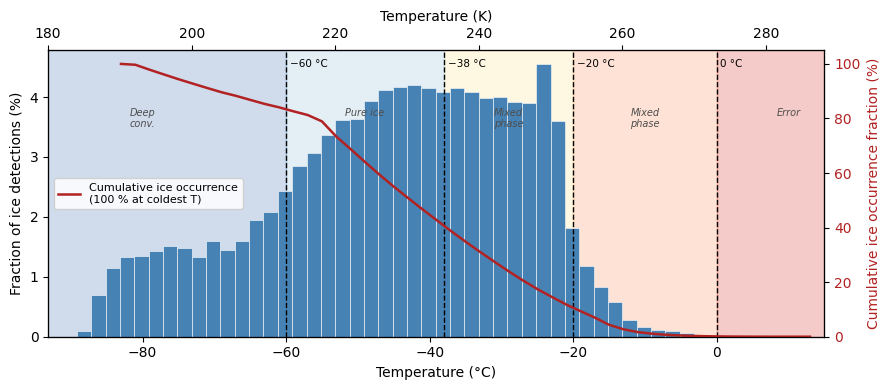

In [161]:
# ── Figure T4 — Histogram with temperature zone shading ─────────────────────
bins        = np.arange(180, 276, 2)
hist_c, edges = np.histogram(t_v, bins=bins, weights=w_v)
hist_frac   = hist_c / hist_c.sum() * 100
centers_c   = 0.5 * (edges[:-1] + edges[1:]) - 273.15   # in °C

# ── Empirical f_ice(T) from EarthCARE Dec 2025 ───────────────────────────────
from scipy.interpolate import interp1d

# 1. Coarsen lat 0.5° → 1°: average adjacent pairs (360 → 180 cells)
tmp_coarse = np.nanmean(tmp_plot.reshape(180, 2, tmp_plot.shape[1]), axis=1)

# 2. Interpolate height axis onto h_c_plot grid
tmp_matched = np.full((180, len(h_c_plot)), np.nan)
for i in range(180):
    row = tmp_coarse[i]
    finite = np.isfinite(row)
    if finite.sum() > 3:
        fi = interp1d(h_t_plot[finite], row[finite], bounds_error=False, fill_value=np.nan)
        tmp_matched[i] = fi(h_c_plot)

# 3. Raw occurrence (not pre-masked) so warm/clear cells with 0 ice are included
ice_n_full = ice_n[:, h_mask_c].astype(float)
tot_n_full = tot_n[:, h_mask_c].astype(float)
occ_full   = np.where(tot_n_full >= MIN_COUNT, ice_n_full / tot_n_full * 100, np.nan)

# 4. Bin by temperature, weighted by total_count; also track total weight per bin
T_emp_bins    = np.arange(-100, 16, 2)
T_emp_centers = 0.5 * (T_emp_bins[:-1] + T_emp_bins[1:])

T_flat = tmp_matched.ravel() - 273.15
f_flat = occ_full.ravel()
w_flat = tot_n_full.ravel()
valid_e = np.isfinite(T_flat) & np.isfinite(f_flat) & np.isfinite(w_flat) & (w_flat >= MIN_COUNT)

f_empirical = np.full(len(T_emp_centers), np.nan)
w_per_bin   = np.full(len(T_emp_centers), np.nan)
for k, (lo, hi) in enumerate(zip(T_emp_bins[:-1], T_emp_bins[1:])):
    mask_b = valid_e & (T_flat >= lo) & (T_flat < hi)
    if mask_b.sum() >= 5:
        f_empirical[k] = np.average(f_flat[mask_b], weights=w_flat[mask_b])
        w_per_bin[k]   = w_flat[mask_b].sum()

# 5. Cumulative ice occurrence fraction — starts at 100 % at coldest temperatures
#    ice_per_bin ∝ number of ice detections in each bin
#    cumsum from cold end gives: "fraction of all ice detections at T or colder"
ice_per_bin = np.where(
    np.isfinite(f_empirical) & np.isfinite(w_per_bin),
    f_empirical / 100.0 * w_per_bin,
    0.0,
)
cum_ice      = np.cumsum(ice_per_bin[::-1])[::-1]   # remaining from cold end
total_ice    = ice_per_bin.sum()
f_cumulative = np.where(
    np.isfinite(f_empirical),
    cum_ice / total_ice * 100.0,
    np.nan,
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

# Shaded zones
zone_ranges_c = [
    (0,    20,   ZONES[0][3], ZONES[0][0]),
    (-20,   0,   ZONES[1][3], ZONES[1][0]),
    (-38, -20,   ZONES[2][3], ZONES[2][0]),
    (-60, -38,   ZONES[3][3], ZONES[3][0]),
    (-100, -60,  ZONES[4][3], ZONES[4][0]),
]
for x0, x1, col, lbl in zone_ranges_c:
    ax.axvspan(x0, x1, color=col, alpha=0.25, zorder=0)

# Histogram bars
ax.bar(centers_c, hist_frac, width=2.0,
       color="steelblue", edgecolor="white", linewidth=0.4, zorder=2)

# Threshold lines
thresholds = [(0, "0 °C"), (-20, "−20 °C"), (-38, "−38 °C"), (-60, "−60 °C")]
for t_c, lbl in thresholds:
    ax.axvline(t_c, color="black", linewidth=1.0, linestyle="--", zorder=3)
    ax.text(t_c + 0.5, ax.get_ylim()[1] * 0.97, lbl,
            fontsize=7.5, va="top", ha="left", color="black")

# Zone labels along top
zone_label_pos = [(10, "Error"), (-10, "Mixed\nphase"), (-29, "Mixed\nphase"),
                  (-49, "Pure ice"), (-80, "Deep\nconv.")]
for xpos, lbl in zone_label_pos:
    ax.text(xpos, ax.get_ylim()[1] * 0.80, lbl,
            fontsize=7, ha="center", va="top", color="0.3", style="italic")

ax.set_xlabel("Temperature (°C)", fontsize=10)
ax.set_ylabel("Fraction of ice detections (%)", fontsize=10)
ax.set_xlim(edges[0] - 273.15, 15)

# ── Right y-axis: cumulative ice occurrence fraction (100 % at coldest) ───────
ax_ice = ax.twinx()
ax_ice.plot(T_emp_centers, f_cumulative, color="firebrick", linewidth=1.8,
            linestyle="-", zorder=5, label="Cumulative ice occurrence\n(100 % at coldest T)")

ax_ice.set_ylim(0, 105)
ax_ice.set_xlim(edges[0] - 273.15, 15)
ax_ice.set_ylabel("Cumulative ice occurrence fraction (%)", fontsize=10, color="firebrick")
ax_ice.tick_params(axis="y", labelcolor="firebrick")
ax_ice.legend(loc="center left", fontsize=8, framealpha=0.85)

# Secondary x-axis in Kelvin
ax2 = ax.twiny()
ax2.set_xlim(edges[0], 288.15)
ax2.set_xlabel("Temperature (K)", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "T4_ice_temperature_histogram_zones.png", dpi=300, bbox_inches="tight")
print("Saved T4_ice_temperature_histogram_zones.png")
plt.show()

## Figure T4.5 — Cumulative temperature distribution of ice cloud detections

Starting from 0 °C, shows what fraction of all ice cloud detections are found at that temperature or colder.  
At 0 °C: 0 %; increases toward 100 % as temperature drops.

Saved T4.5_ice_cumulative_temperature.png


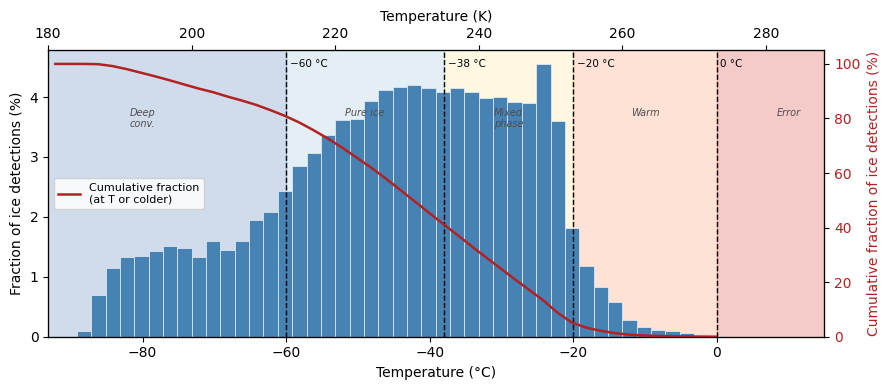

In [162]:
# ── Figure T4.5 — Histogram + cumulative ice cloud fraction (right y-axis) ───
bins_c45     = np.arange(180, 276, 2)
hist_c45, edges_c45 = np.histogram(t_v, bins=bins_c45, weights=w_v)
hist_frac45  = hist_c45 / hist_c45.sum() * 100
centers_c45  = 0.5 * (edges_c45[:-1] + edges_c45[1:]) - 273.15   # °C

# Reverse cumulative sum of histogram fractions:
# at temperature T, "fraction of all ice detections at T or colder"
# → 100 % at coldest bin, decreases to ~0 % at warmest bin
cum_cold = np.cumsum(hist_c45[::-1])[::-1] / hist_c45.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4))

# Shaded zones
for x0, x1, col, lbl in zone_ranges_c:
    ax.axvspan(x0, x1, color=col, alpha=0.25, zorder=0)

# Histogram bars
ax.bar(centers_c45, hist_frac45, width=2.0,
       color="steelblue", edgecolor="white", linewidth=0.4, zorder=2)

# Threshold lines + zone labels
for t_c, lbl in [(0, "0 °C"), (-20, "−20 °C"), (-38, "−38 °C"), (-60, "−60 °C")]:
    ax.axvline(t_c, color="black", linewidth=1.0, linestyle="--", zorder=3)
    ax.text(t_c + 0.5, ax.get_ylim()[1] * 0.97, lbl,
            fontsize=7.5, va="top", ha="left", color="black")

for xpos, lbl in [(10, "Error"), (-10, "Warm"), (-29, "Mixed\nphase"),
                  (-49, "Pure ice"), (-80, "Deep\nconv.")]:
    ax.text(xpos, ax.get_ylim()[1] * 0.80, lbl,
            fontsize=7, ha="center", va="top", color="0.3", style="italic")

ax.set_xlabel("Temperature (°C)", fontsize=10)
ax.set_ylabel("Fraction of ice detections (%)", fontsize=10)
ax.set_xlim(edges_c45[0] - 273.15, 15)

# ── Right y-axis: cumulative fraction (100 % at coldest) ─────────────────────
ax_cum = ax.twinx()
ax_cum.plot(centers_c45, cum_cold, color="firebrick", linewidth=1.8, zorder=4,
            label="Cumulative fraction\n(at T or colder)")

ax_cum.set_ylabel("Cumulative fraction of ice detections (%)", fontsize=10, color="firebrick")
ax_cum.tick_params(axis="y", labelcolor="firebrick")
ax_cum.set_ylim(0, 105)
ax_cum.set_xlim(edges_c45[0] - 273.15, 15)
ax_cum.legend(loc="center left", fontsize=8, framealpha=0.85)

# Secondary x-axis in Kelvin
ax2 = ax.twiny()
ax2.set_xlim(edges_c45[0], 288.15)
ax2.set_xlabel("Temperature (K)", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "T4.5_ice_cumulative_temperature.png", dpi=300, bbox_inches="tight")
print("Saved T4.5_ice_cumulative_temperature.png")
plt.show()

## Figure T5 — Zonal-mean ice water path (column-integrated IWC)

IWP here is the vertical integral of the occurrence-weighted IWC:

IWP(lat) = Σ_h [ IWC_mean(lat, h) × occurrence(lat, h) × Δz ]

where Δz = 100 m. This represents the all-sky column ice burden and is analogous
to the frozen water path (FWP) in multi-sensor datasets, though note that the
ATL-ICE retrieval captures cloud ice only — snow and graupel are not included.

IWP range: 0.0000 – 21.0888 kg m⁻²
  Tropical max (|lat| ≤ 10°): 11.9425 kg m⁻²
Saved T5_ice_water_path_zonal.png


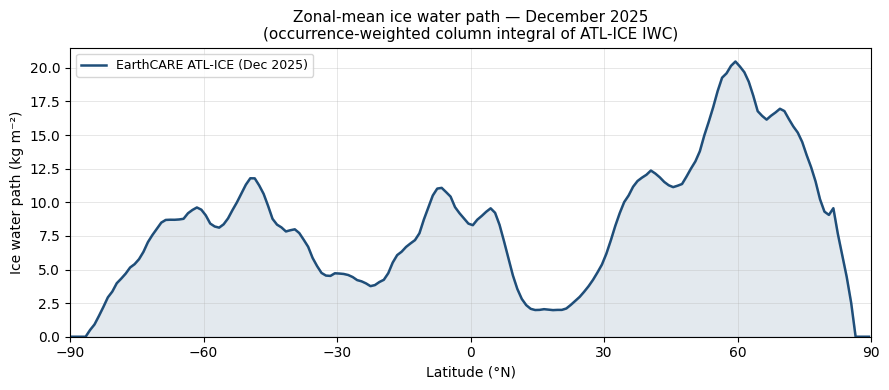

In [163]:
from scipy.ndimage import uniform_filter1d

DZ = 100.0  # m per height level

# Exclude warm retrieval errors for the IWP integral
warm_error = ice_t_plot > 273.15
iwc_clean  = np.where(warm_error | ~np.isfinite(iwc_plot), 0.0, iwc_plot)
occ_clean  = np.where(warm_error | ~np.isfinite(occ_plot), 0.0, occ_plot)

# Occurrence-weighted column integral → kg m⁻²
iwp = np.sum(iwc_clean * occ_clean * DZ, axis=1)   # shape (n_lat,)

# Light smoothing over latitude for visual clarity (window = 5°)
iwp_smooth = uniform_filter1d(iwp, size=5)

print(f"IWP range: {iwp.min():.4f} – {iwp.max():.4f} kg m⁻²")
print(f"  Tropical max (|lat| ≤ 10°): {iwp[np.abs(lat_c) <= 10].max():.4f} kg m⁻²")

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(lat_c, iwp_smooth, color="#1f4e79", linewidth=1.8,
        label="EarthCARE ATL-ICE (Dec 2025)")
ax.fill_between(lat_c, 0, iwp_smooth, alpha=0.12, color="#1f4e79")

ax.set_xlabel("Latitude (°N)", fontsize=10)
ax.set_ylabel("Ice water path (kg m⁻²)", fontsize=10)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.35, linewidth=0.6)
ax.legend(fontsize=9, framealpha=0.8)
ax.set_title(
    "Zonal-mean ice water path — December 2025\n"
    "(occurrence-weighted column integral of ATL-ICE IWC)",
    fontsize=11,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "T5_ice_water_path_zonal.png", dpi=300, bbox_inches="tight")
print("Saved T5_ice_water_path_zonal.png")
plt.show()